Data overview, target analysis, temporal exploration, behavioral analysis
before churn (prediction-window justification), and feature relationships.

Logic lives in `src/churn/eda/`; this notebook calls it and adds interpretation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import INTERIM_DIR
from churn.eda.overview import run_overview
from churn.eda.target_analysis import run_target_analysis, churn_rate_by_tenure, churn_rate_by_age_bucket
from churn.eda.temporal import run_temporal_analysis, explore_inactivity_vs_reference
from churn.eda.behavioral import run_behavioral_analysis
from churn.eda.correlations import run_correlation_analysis

from pathlib import Path

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

subscriber_static = pd.read_parquet(INTERIM_DIR / "subscriber_static.parquet")
monthly_usage = pd.read_parquet(INTERIM_DIR / "monthly_usage.parquet")

## 1. Data overview

In [2]:
run_overview(subscriber_static, monthly_usage)


=== subscriber_static: shape=(423766, 22) ===
churn                                   object
classe_anciennete                       object
subscriber_id                            int64
msisdn                                  object
sales_channel_description              float64
date_activation                 datetime64[ns]
churn_date                      datetime64[ns]
first_call_date                 datetime64[ns]
last_call_date                  datetime64[ns]
first_recharge_date             datetime64[ns]
first_recharge_amount                  float64
last_international_call_date    datetime64[ns]
original_operator                       object
dat_attrib_kridi                datetime64[ns]
dat_remb_kridi_net              datetime64[ns]
ported_in_request_date          datetime64[ns]
is_churn                                  bool
age                                    float64
marital_status                          object
gender                                  object
customer_lang


--- subscriber_static: missingness ---
                              n_missing  pct_missing
sales_channel_description        423766       100.00
dat_attrib_kridi                 423764       100.00
ported_in_request_date           418750        98.82
last_international_call_date     418327        98.72
churn_date                       387510        91.44
dat_remb_kridi_net               278343        65.68
marital_status                    99158        23.40
gender                            68044        16.06
first_recharge_amount             58199        13.73
first_recharge_date               58199        13.73
customer_language                 47393        11.18
last_call_date                    25352         5.98
first_call_date                   25352         5.98
age                               20683         4.88
contact_city                       8792         2.07



--- monthly_usage: missingness ---
                         n_missing  pct_missing
device_type                  24166         0.91
flag_smartphone              24166         0.91
number_of_reactivations          1         0.00

--- subscriber_static: key numeric variable distributions ---
        count       mean        std  min    1%   25%   50%   75%   99%    max
age  403083.0  43.160277  14.452083  0.0  19.0  32.0  42.0  54.0  80.0  100.0

--- monthly_usage: key numeric variable distributions ---


                        count          mean           std  min   1%  25%  \
recharge_amount     2668258.0  9.100415e+03  2.355892e+04  0.0  0.0  0.0   
mou_onnet           2668258.0  5.152079e+03  1.500426e+04  0.0  0.0  0.0   
data_trafic_volume  2668258.0  1.039364e+10  3.791813e+10  0.0  0.0  0.0   

                          50%           75%           99%           max  
recharge_amount        1000.0  1.000000e+04  8.300000e+04  7.098302e+06  
mou_onnet               360.0  4.128000e+03  6.652243e+04  8.682810e+05  
data_trafic_volume  1585875.5  4.519031e+09  1.387869e+11  2.272043e+12  

--- subscriber_static: duplicate check on key=['subscriber_id'] ---
  duplicate rows: 0 (expected 0)



--- monthly_usage: duplicate check on key=['subscriber_id', 'period_date'] ---
  duplicate rows: 0 (expected 0)


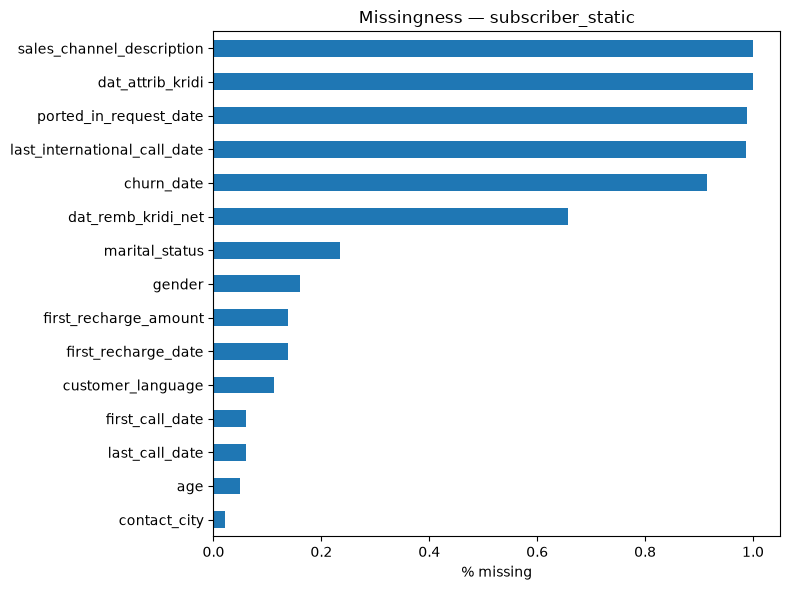

In [3]:
missingness = subscriber_static.isna().mean().sort_values(ascending=False)
missingness = missingness[missingness > 0]

fig = plt.figure(figsize=(8, 6))
missingness.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missingness — subscriber_static")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "01_missingness")
plt.show()

**Observations — Data overview**

- **Missing values are consistent with the raw audit.** Most variables have acceptable completeness. The high missing rate for churn_date (91.44%) is expected because it is only considered for subscribers with churn = Yes.
- **Some variables contain little or no usable information.** sales_channel_description and dat_attrib_kridi are almost entirely missing and will be considered for removal during feature selection.  
- **Data cleaning was effective.** Invalid age values were converted to missing values rather than corrected, preserving data integrity.
- **Usage variables are highly right-skewed and contain many zero values.** Many subscribers have little or no activity while a small number are heavy users. This will be taken into account during feature engineering and model preparation.
- **Usage-related missing values have been resolved.** Variables such as data_trafic_volume, total_data_revenu_amount, and total_voice_revenu_amount were filled with zero where they represent genuine periods of no activity.
  

## 2. Target analysis

In [4]:
from churn.eda.target_analysis import run_target_analysis

run_target_analysis(subscriber_static)


--- Overall churn rate ---
is_churn
False    387510
True      36256
Name: count, dtype: int64
churn rate: 8.56%



--- Churn rate by gender ---
        churn_rate  n_subscribers
gender                           
U         0.111111              9
F         0.100296          97312
M         0.098169         258401
NaN       0.016578          68044
  (Note: 1 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)

--- Churn rate by marital_status ---
                churn_rate  n_subscribers
marital_status                           
Celibataire       0.107447         278585
Marie             0.077977          45962
Veuf              0.068966             29
Divorce           0.031250             32
NaN               0.027592          99158
  (Note: 2 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)



--- Churn rate by customer_language ---
                   churn_rate  n_subscribers
customer_language                           
Anglais              0.115042         235331
Arabe                0.053307          78901
Français             0.052783          62047
NaN                  0.035870          47393
Italien              0.021277             94
  (Note: 1 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)



--- Churn rate by contact_city ---
                churn_rate  n_subscribers
contact_city                             
BOUSLAM                1.0              1
BUCHAMA                1.0              1
BUO-ARADA              1.0              1
BOU ZGAM               1.0              1
BOU-ARADAA             1.0              1
...                    ...            ...
zlg                    0.0              1
zohor                  0.0              1
zouagha                0.0              4
  TINJA                0.0              2
 BANI KHEDECH          0.0              1

[20245 rows x 2 columns]
  (Note: 19785 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)



--- Churn rate by age bucket (excluding 20683 null-age rows) ---
            churn_rate  n_subscribers
age_bucket                           
[0, 10)       0.047619             63
[10, 20)      0.141145           5923
[20, 30)      0.102047          74407
[30, 40)      0.092231          98069
[40, 50)      0.091676          94049
[50, 60)      0.078111          70886
[60, 70)      0.072876          43018
[70, 80)      0.079347          12502
[80, 90)      0.076923           3783
[90, 100)     0.081365            381



--- Churn rate by tenure (classe_anciennete) ---
                     churn_rate  n_subscribers
classe_anciennete                             
0 to 3 Months          0.000751          21303
3 to 6 Months          0.069978          41256
6 to 12 Months         0.178876          67952
12 to 36 Months        0.131871          89777
More than 36 Months    0.045995         203478



--- Churn rate by tenure (classe_anciennete) ---
                     churn_rate  n_subscribers
classe_anciennete                             
0 to 3 Months          0.000751          21303
3 to 6 Months          0.069978          41256
6 to 12 Months         0.178876          67952
12 to 36 Months        0.131871          89777
More than 36 Months    0.045995         203478


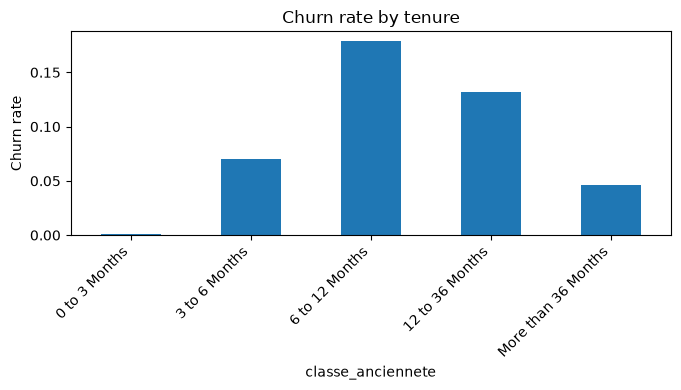


--- Churn rate by age bucket (excluding 20683 null-age rows) ---
            churn_rate  n_subscribers
age_bucket                           
[0, 10)       0.047619             63
[10, 20)      0.141145           5923
[20, 30)      0.102047          74407
[30, 40)      0.092231          98069
[40, 50)      0.091676          94049
[50, 60)      0.078111          70886
[60, 70)      0.072876          43018
[70, 80)      0.079347          12502
[80, 90)      0.076923           3783
[90, 100)     0.081365            381


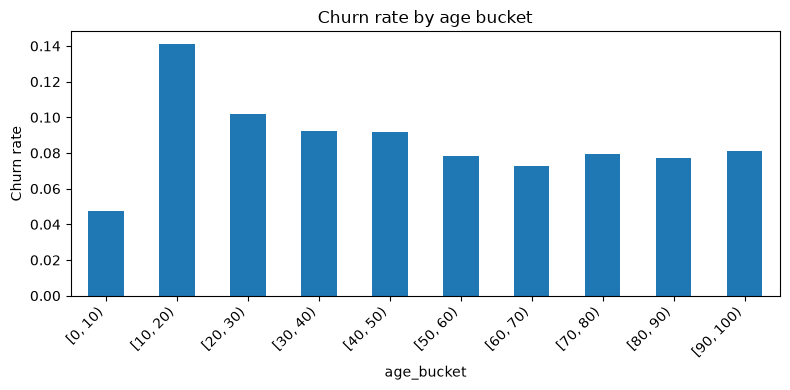

In [5]:
from churn.eda.target_analysis import churn_rate_by_tenure, churn_rate_by_age_bucket

tenure = churn_rate_by_tenure(subscriber_static)
fig = plt.figure(figsize=(7, 4))
tenure["churn_rate"].plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by tenure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "02_churn_rate_by_tenure")
plt.show()

age = churn_rate_by_age_bucket(subscriber_static)
fig = plt.figure(figsize=(8, 4))
age["churn_rate"].plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by age bucket")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "02_churn_rate_by_age")
plt.show()

**Observations — Target analysis**

- **Overall churn rate: 8.56%** (36,256 / 423,766)

- **Demographic variables show differences in churn across groups.**: For example, subscribers with customer_language = Anglais have a higher churn rate (~11.5%) than those with Arabe or Français (~5%).    
- **contact_city is not usable in its current form.** The extremely high number of distinct values indicates inconsistent text formatting (capitalization, spelling variations, extra spaces, etc.). A normalization step will be required before this variable can be used for analysis or feature engineering.  
- **Age shows a meaningful relationship with churn.** The highest churn rate is observed among subscribers aged 10–20 years, after which churn gradually decreases with age. The 0–10 age group is too small to draw reliable conclusions.  
- **Tenure (classe_anciennete) is strongly associated with churn.** The churn rate peaks for subscribers with 6–12 months of tenure (17.9%) and then steadily decreases for longer-tenured customers. This confirms the pattern already identified during the raw data audit.

## 3. Temporal exploratory analysis

In [6]:
from churn.eda.temporal import run_temporal_analysis

run_temporal_analysis(monthly_usage, subscriber_static)


--- Timeline coverage ---
monthly_usage period_date range: 2024-07-01 00:00:00 -> 2025-01-01 00:00:00
unique periods: 7
date_activation range: 2002-12-26 00:00:00 -> 2025-02-19 18:15:17
churn_date range (churners only): 2024-08-15 00:00:00 -> 2025-03-15 00:00:00

--- Tenure distribution ---
                     n_subscribers    pct
classe_anciennete                        
0 to 3 Months                21303   5.03
3 to 6 Months                41256   9.74
6 to 12 Months               67952  16.04
12 to 36 Months              89777  21.19
More than 36 Months         203478  48.02

--- Exploratory inactivity vs reference_date=2025-01-01 00:00:00 ---
churn=True:
count    31794.000000
mean       200.435522
std        185.621431
min        -78.000000
10%         69.000000
25%        104.000000
50%        168.000000
75%        257.000000
90%        343.000000
max       3244.000000
Name: inactivity_days, dtype: float64

churn=False:


count    366620.000000
mean         -2.120618
std         244.614081
min         -78.000000
10%         -78.000000
25%         -78.000000
50%         -77.000000
75%         -18.000000
90%         106.000000
max        3322.000000
Name: inactivity_days, dtype: float64

--- Churn events by month (count of churn_date falling in that month) ---
churn_month
2024-08      151
2024-09      345
2024-10      427
2024-11      388
2024-12    16850
2025-01    18090
2025-02        1
2025-03        4
Freq: M, dtype: int64

--- churn_date concentration ---
total churners: 36256
distinct churn_date values: 201

top 15 exact dates by churner count:
churn_date
2024-12-25 23:59:59    1569
2024-12-15 23:59:59     815
2024-12-06 23:59:59     696
2024-12-04 23:59:59     660
2025-01-29 23:59:59     657
2024-12-10 23:59:59     641
2025-01-20 23:59:59     636
2025-01-08 23:59:59     631
2025-01-30 23:59:59     625
2025-01-27 23:59:59     622
2024-12-09 23:59:59     617
2024-12-07 23:59:59     615
2025-01-26 23:


--- Exploratory inactivity vs reference_date=2025-01-01 00:00:00 ---
churn=True:
count    31794.000000
mean       200.435522
std        185.621431
min        -78.000000
10%         69.000000
25%        104.000000
50%        168.000000
75%        257.000000
90%        343.000000
max       3244.000000
Name: inactivity_days, dtype: float64

churn=False:


count    366620.000000
mean         -2.120618
std         244.614081
min         -78.000000
10%         -78.000000
25%         -78.000000
50%         -77.000000
75%         -18.000000
90%         106.000000
max        3322.000000
Name: inactivity_days, dtype: float64


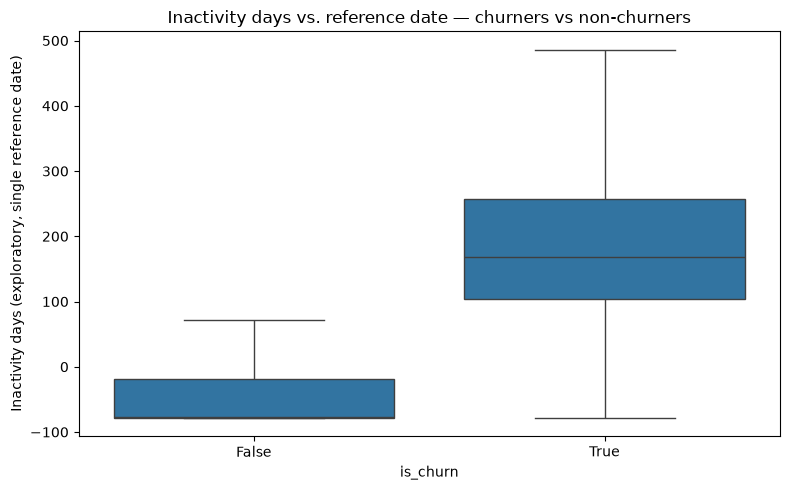

In [7]:
from churn.eda.temporal import explore_inactivity_vs_reference

reference_date = monthly_usage["period_date"].max()
inactivity = explore_inactivity_vs_reference(subscriber_static, reference_date)

fig = plt.figure(figsize=(8, 5))
sns.boxplot(data=inactivity, x="is_churn", y="inactivity_days", showfliers=False)
plt.title("Inactivity days vs. reference date — churners vs non-churners")
plt.xlabel("is_churn")
plt.ylabel("Inactivity days (exploratory, single reference date)")
plt.tight_layout()
save_fig(fig, "03_inactivity_by_churn")
plt.show()

**Observations — Temporal exploratory analysis**

- **The available usage history covers July 2024 to January 2025 (7 months).** However, `last_call_date` and `churn_date` extend to March 2025, meaning the target information is available beyond the monthly usage history. This provides a short observation period after the last available usage data.  
- **The subscriber base is mainly composed of long-term customers.** Nearly half of the subscribers (48%) have more than 36 months of tenure, while only 5% have been customers for less than 3 months.  
- **Churners generally show much longer inactivity periods than non-churners.** This suggests that recent customer activity is likely to be an informative predictor of churn. The negative inactivity values observed for many non-churners are expected because the chosen reference date precedes many of their recorded `last_call_date` values.  

## 4. Behavioral analysis before churn (prediction-window justification)

In [8]:
from churn.eda.behavioral import run_behavioral_analysis

results = run_behavioral_analysis(monthly_usage, subscriber_static)


--- Usage trend vs. days-before-churn (churners only, 15-day buckets) ---
        recharge_amount  number_of_recharges    mou_onnet  data_trafic_volume  \
bucket                                                                          
0              8.273254             0.001477    12.602529        1.654963e+08   
15            11.492829             0.004561    43.990164        6.508526e+08   
30            18.314149             0.006052    56.042138        3.637878e+09   
45            22.224111             0.008389   140.541444        1.629147e+09   
60            47.888161             0.014992   137.363260        5.624327e+09   
75            22.668468             0.007555    80.922190        1.588926e+09   
90           160.383853             0.120548   171.505625        4.866218e+09   
105          636.830218             0.601350   229.778553        1.364513e+09   
120          915.035870             0.862686   351.328283        3.885190e+09   
135          731.846807           


--- Usage by calendar month: churners vs non-churners ---
            recharge_amount              number_of_recharges            \
is_churn              False        True                False     True    
period_date                                                              
2024-07-01     11464.047118  2835.477690            5.568878  1.500997   
2024-08-01     11505.283065  1014.724071            5.549306  0.870260   
2024-09-01     10969.019765   636.508915            5.241830  0.594914   
2024-10-01      9884.882763   240.111307            5.018259  0.217894   
2024-11-01      8935.307873    17.944279            4.562727  0.005685   
2024-12-01      8931.519683    13.408006            4.431800  0.003449   
2025-01-01      8537.850549     8.531443            4.279206  0.002786   

               mou_onnet             data_trafic_volume                
is_churn           False       True               False         True   
period_date                                             


--- % of churners with any activity, by days-before-churn bucket ---
        pct_active
bucket            
0         0.002659
15        0.008572
30        0.007251
45        0.008278
60        0.009306
75        0.006728
90        0.111338
105       0.279027
120       0.268998
135       0.165177
150       0.176832
165       0.233097
180       0.384077
195       0.412685
210       0.433460


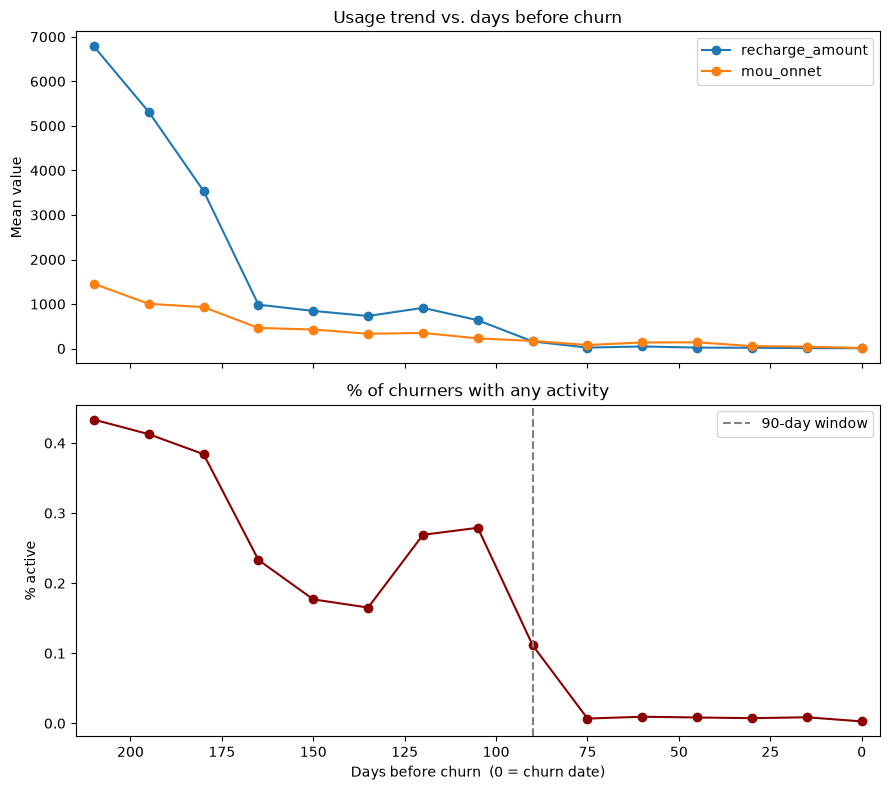

In [9]:
trend = results["trend"]
activity = results["activity_decline"]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(trend.index, trend["recharge_amount"], marker="o", label="recharge_amount")
axes[0].plot(trend.index, trend["mou_onnet"], marker="o", label="mou_onnet")
axes[0].set_ylabel("Mean value")
axes[0].set_title("Usage trend vs. days before churn")
axes[0].legend()

axes[1].plot(activity.index, activity["pct_active"], marker="o", color="darkred")
axes[1].axvline(90, color="gray", linestyle="--", label="90-day window")
axes[1].set_xlabel("Days before churn  (0 = churn date)")
axes[1].set_ylabel("% active")
axes[1].set_title("% of churners with any activity")
axes[1].legend()

max_bucket = trend.index.max()
for ax in axes:
    ax.set_xlim(max_bucket + 5, -5)  # explicit reversed range: high values on the left, 0 on the right

plt.tight_layout()
save_fig(fig, "04_behavioral_window_justification")
plt.show()

**Observations — Behavioral analysis before churn**

- **Customer activity declines progressively before churn,**
  then it drops sharply and then remains very low in the last 90 days. pct_active falls from ~41–43% (195–210 days before churn) to ~11–28% (90–135 days before), then stays below 1% during the final ~75 days.
- **A 90-day window** appears to provide a good balance between predictive signal and intervention time.

## 5. Feature relationships


--- Correlation matrix (16 numeric usage features) ---
                             recharge_amount  number_of_recharges  \
recharge_amount                         1.00                 0.70   
number_of_recharges                     0.70                 1.00   
number_of_sms_onnet                     0.23                 0.32   
number_of_sms_offnet                    0.06                 0.07   
number_of_sms_international             0.03                 0.01   
mou_onnet                               0.21                 0.23   
mou_offnet_mobile                       0.23                 0.24   
mou_offnet_fix                          0.04                 0.02   
mou_international                       0.04                 0.02   
consumption_revenue                     0.47                 0.42   
arpu_out_without_bonus                  0.69                 0.55   
incoming_revenue                        0.07                 0.09   
data_trafic_volume                      0.07   

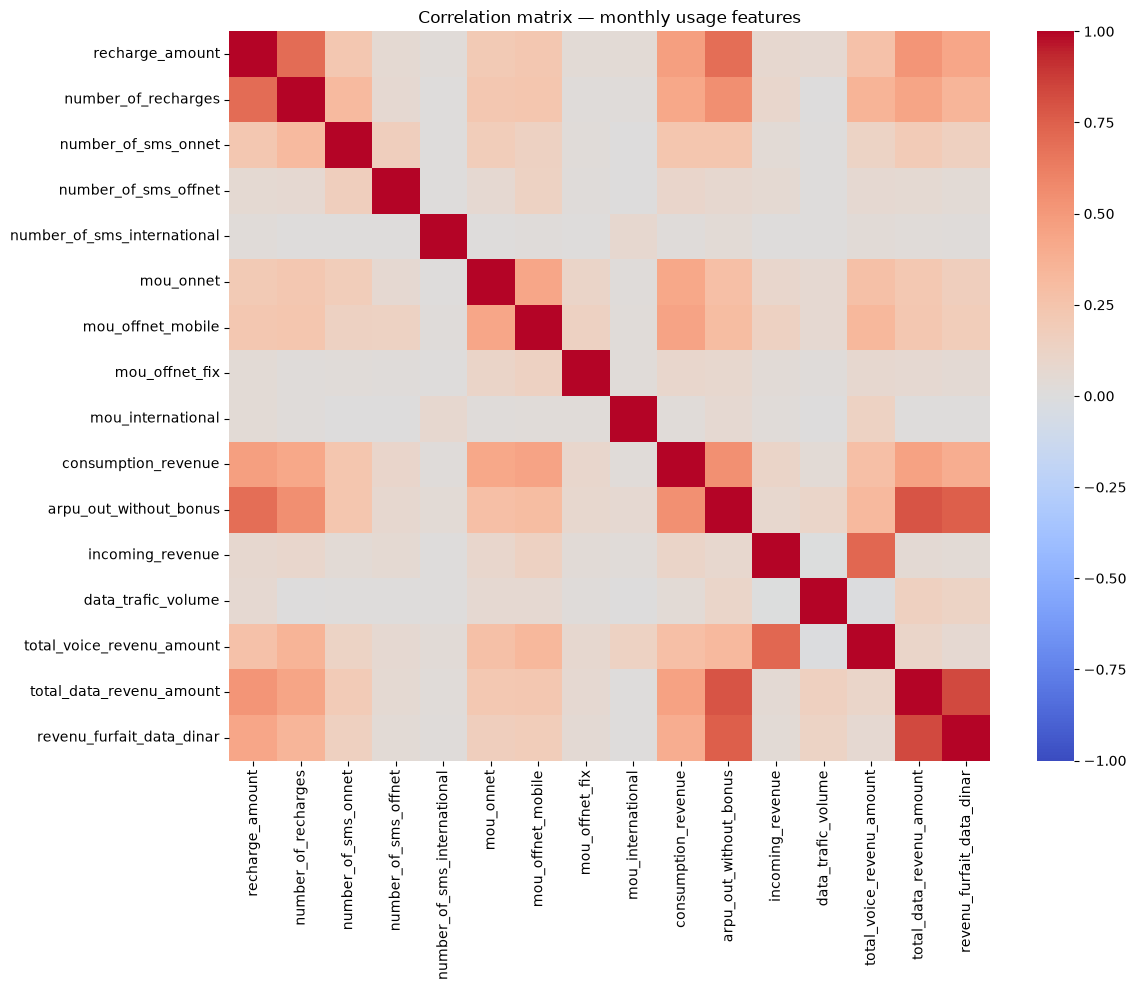

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from churn.eda.correlations import run_correlation_analysis

corr_results = run_correlation_analysis(monthly_usage)

fig=plt.figure(figsize=(12, 10))
sns.heatmap(corr_results["correlation_matrix"], annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix — monthly usage features")
plt.tight_layout()
save_fig(fig, "05_correlation_heatmap")
plt.show()

**Observations — Feature relationships**  
- Only five feature pairs have a high correlation (|r| ≥ 0.7), and all are expected because they measure similar or related concepts:

  - Data revenue features (`revenu_furfait_data_dinar` and `total_data_revenu_amount`).  
  - ARPU with data revenue features.  
  - `incoming_revenue` with `total_voice_revenu_amount`.  
  - `number_of_recharges` with `recharge_amount`.    
- Most feature pairs have low correlation (|r| < 0.3), indicating that the dataset captures different aspects of customer behavior rather than containing many redundant variables.